<h1> Анализ лояльности пользователей Яндекс Афиши с помощью Python </h1>

<h3>Задача</h3>
<ul>
    <li>Понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно.</li>
    <li>Выявление гипотез, которые помогут для следующих задач:
        <ul>
            <li>Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.</li>
            <li>Точно настраивать рекламу на аудитории с высокой вероятностью возврата.</li>
            <li>Оптимизировать маркетинговые бюджеты.</li>
            <li>Повысить общий уровень удержания клиентов.</li>
        </ul>
    </li>
</ul>

<h3>Цель проекта</h3>
<p>Проанализировать профили пользователей для выявления закономерностей между вероятностью возврата пользователя и его показателями.</p>

<h3>Этапы, необходимые для решения кейса</h3>
<ol>
    <li>Написать SQL-запрос для выгрузки необходимых показателей.</li>
    <li>Провести предобработку данных, которая включает в себя:
        <ul>
            <li>Приведение признаков к единому стандарту</li>
            <li>Обработку пропусков</li>
            <li>Удаление дубликатов</li>
            <li>Преобразование типов данных</li>
        </ul>
    </li>
    <li>Создание профилей пользователей для дальнейшего анализа</li>
    <li>Выявление признаков, влияющих на вероятность возвращения (образ человека, готового на большее количество заказов)</li>
    <li>Выводы и рекомендации по увеличению конверсии между пользователями со 2 заказом и 1</li>
</ol>

<h1>Этапы выполнения проекта</h1>

<h3>1. Загрузка данных и их предобработка</h3>

<hr>

<h4>Задача 1.1. SQL-запрос, выгружающий в датафрейм pandas необходимые данные</h4>

<p>Выгрузка из базы данных SQL должна позволить собрать следующие данные:</p>

<ul>
    <li><code>user_id</code> — уникальный идентификатор пользователя, совершившего заказ;</li>
    <li><code>device_type_canonical</code> — тип устройства, с которого был оформлен заказ (<code>mobile</code> — мобильные устройства, <code>desktop</code> — стационарные);</li>
    <li><code>order_id</code> — уникальный идентификатор заказа;</li>
    <li><code>order_dt</code> — дата создания заказа (используйте данные <code>created_dt_msk</code>);</li>
    <li><code>order_ts</code> — дата и время создания заказа (используйте данные <code>created_ts_msk</code>);</li>
    <li><code>currency_code</code> — валюта оплаты;</li>
    <li><code>revenue</code> — выручка от заказа;</li>
    <li><code>tickets_count</code> — количество купленных билетов;</li>
    <li><code>days_since_prev</code> — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;</li>
    <li><code>event_id</code> — уникальный идентификатор мероприятия;</li>
    <li><code>service_name</code> — название билетного оператора;</li>
    <li><code>event_type_main</code> — основной тип мероприятия (театральная постановка, концерт и так далее);</li>
    <li><code>region_name</code> — название региона, в котором прошло мероприятие;</li>
    <li><code>city_name</code> — название города, в котором прошло мероприятие.</li>
</ul>

<hr>

In [2]:
import pandas as pd
import phik
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

db_config = {'user': 'praktikum_student', 
             'pwd': 'YOUR_PASSWORD',  # заполните перед запуском 
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432,
             'db': 'data-analyst-afisha' 
             }
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)
engine = create_engine(connection_string)
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,  
    c.city_name,
    r.region_name
FROM afisha.purchases as p
INNER JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop') and e.event_type_main != 'фильм'
ORDER BY p.user_id
'''
df = pd.read_sql_query(query, con=engine)

<hr>

<h4>Задача 1.2. Изучение общей информации о выгруженных данных</h4>

<p>Необходимо:</p>
<ul>
    <li>Оценить корректность выгрузки данных</li>
    <li>Проанализировать объём полученных данных</li>
    <li>Определить дальнейшие шаги по предобработке</li>
</ul>

<hr>

In [3]:
print(df.info())
print(df.head()) 

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


Проверим корректность выгруженных данных

In [4]:
print("Отрицательная выручка:", (df['revenue'] < 0).sum())
print("Нулевая выручка:", (df['revenue'] == 0).sum())
print("Нулевое количество билетов:", (df['tickets_count'] == 0).sum())
print("Отрицательное количество билетов:", (df['tickets_count'] < 0).sum())

Отрицательная выручка: 381
Нулевая выручка: 5526
Нулевое количество билетов: 0
Отрицательное количество билетов: 0


<h4>Выводы по общей информации о выгруженных данных:</h4>
<ul>
    <li>Общий объём: 290 611 строк</li>
    <li>Пропуски только в столбце <code>days_since_prev</code>, которые относятся к первым покупкам пользователей</li>
    <li>Данные следующих столбцов можно преобразовать к типу данных <code>category</code> после проверки их уникальных значений:
        <ul>
            <li><code>device_type_canonical</code></li>
            <li><code>currency_code</code></li>
            <li><code>event_type_main</code></li>
            <li><code>service_name</code></li>
            <li><code>city_name</code></li>
            <li><code>region_name</code></li>
        </ul>
    </li>
    <li> В данных присутствуют данные с нулевой выручкой, нужно учесть это при предобработке данных
</ul>

---

<h3> 2. Предобработка данных </h3>


---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Привидём выручку к единой валюте — российскому рублю.

---


In [5]:
exchange = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv', parse_dates=['data'])
df = df.merge(exchange, left_on='order_dt', right_on='data', how='left')
print(df.columns)

Index(['user_id', 'device_type_canonical', 'order_id', 'order_dt', 'order_ts',
       'currency_code', 'revenue', 'tickets_count', 'days_since_prev',
       'event_id', 'event_name', 'event_type_main', 'service_name',
       'city_name', 'region_name', 'data', 'nominal', 'curs', 'cdx'],
      dtype='str')


In [6]:
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
print(df[['revenue', 'revenue_rub', 'curs']][df['currency_code'] == 'kzt'])

         revenue  revenue_rub     curs
70        518.10    98.503762  19.0125
89        347.18    65.731589  18.9330
96        328.77    61.148261  18.5991
277     22021.55  4380.702898  19.8928
460      7397.66  1478.296591  19.9833
...          ...          ...      ...
290484   4735.52   865.359454  18.2738
290485   4735.52   872.363288  18.4217
290486   1849.41   343.072953  18.5504
290488   3698.83   687.209325  18.5791
290489   3698.83   687.209325  18.5791

[5069 rows x 3 columns]


---

**Задача 2.2:** Обработка Пропусков

---

In [7]:
print("Пропуски по столбцам:")
print(df.isnull().sum())

Пропуски по столбцам:
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
city_name                    0
region_name                  0
data                         0
nominal                      0
curs                         0
cdx                          0
revenue_rub                  0
dtype: int64


Пропуски обнаружены только в столбце <code>days_since_prev</code>, они возникают в троках с первым заказом пользователя проверим

In [8]:
print(df['days_since_prev'].isna().sum() == df['user_id'].nunique())

True


Гипотеза подтверждена, эти пропуски можно оставить без изменений

---

**Задача 2.3:** Удаление явных и неявных дубликатов

---

In [9]:
print(f"Явные дубликаты: {df.duplicated().sum()} Повторяющиеся order_id: {df['order_id'].duplicated().sum()}")

Явные дубликаты: 0 Повторяющиеся order_id: 0


Явные дубликаты не найдены проверим неявные 

In [10]:
mask = df.duplicated(subset=['user_id', 'order_ts'], keep=False)
print(f"Неявных дубликатов с одинаковыми 'user_id', 'order_ts': {mask.sum()}, Доля: {round(mask.sum() / len(df), 4)}")
print(df[mask][['user_id', 'order_id', 'order_ts']].head(10))

Неявных дубликатов с одинаковыми 'user_id', 'order_ts': 325, Доля: 0.0011
               user_id  order_id            order_ts
4355   02ea4583333f064   1158638 2024-08-23 22:46:05
4359   02ea4583333f064   1158696 2024-08-23 22:46:05
5710   02ea4583333f064   5271215 2024-10-16 17:49:44
5714   02ea4583333f064   1536363 2024-10-16 17:49:44
6053   02ea4583333f064   4952505 2024-10-27 16:39:40
6080   02ea4583333f064   5070796 2024-10-27 16:39:40
11758  06eb7897f65b433   1123867 2024-08-13 16:31:07
11761  06eb7897f65b433   1123983 2024-08-13 16:31:07
12677  08199117318954f   5592970 2024-07-31 11:52:06
12679  08199117318954f   5593202 2024-07-31 11:52:06


325 значений являются дубликатыми(примерно 0.1%) необходимо их удалить 

In [11]:
print("Количество строк до удаления:", len(df))
df = df.drop_duplicates(subset=['user_id', 'order_ts'], keep='first')
print("После:", len(df))

Количество строк до удаления: 290611
После: 290441


После выгрузки данных было обнаружено - Отрицательная выручка: 381

In [12]:
negative_revenue = df[df['revenue'] < 0]

if len(negative_revenue) > 0:
    display(negative_revenue[['user_id', 'order_id', 'revenue', 'tickets_count']].head(10))

,user_id,order_id,revenue,tickets_count
252,00eb3dc9baa1543,1594653,-2.37,3
4539,02ea4583333f064,2360920,-0.23,3
4544,02ea4583333f064,2361094,-0.15,2
8135,043f669c9f734b1,166780,-1.86,3
8136,043f669c9f734b1,166809,-0.62,1
11342,06727636bf2f465,6620527,-1.58,2
11343,06727636bf2f465,6620498,-1.58,2
11568,067494310c6617f,8333963,-6.18,4
11619,067494310c6617f,4930755,-3.59,1
11622,067494310c6617f,8350029,-10.77,3


Эти значения составляют незначительную часть(около 0.1%) можно их удалить

In [13]:
print(len(df))
df = df[df['revenue'] >= 0]
print(len(df))

290441
290062


---

**Задача 2.4:** Преобразование типов данных

---

In [19]:
df['order_id'] = df['order_id'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')
df['tickets_count'] = df['tickets_count'].astype('int8')
df['revenue_rub'] = df['revenue_rub'].astype('float32')
df['days_since_prev'] = df['days_since_prev'].astype('float32')

columns = ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'city_name', 'region_name']
cat_cols = [col for col in df.columns if df[col].dtype in ['object', 'string']]
for col in cat_cols:
    df[col] = df[col].astype('category')
for column in columns:
  print(f"\nColumn: {column}")
  print("Unique values:", df[column].unique())
  print("Missing values count:", df[column].isna().sum())
  print("Value counts:")
  print(df[column].value_counts(dropna=False), "\n")



Column: device_type_canonical
Unique values: ['mobile', 'desktop']
Categories (2, str): ['desktop', 'mobile']
Missing values count: 0
Value counts:
device_type_canonical
mobile     232009
desktop     58053
Name: count, dtype: int64 


Column: currency_code
Unique values: ['rub', 'kzt']
Categories (2, str): ['kzt', 'rub']
Missing values count: 0
Value counts:
currency_code
rub    284996
kzt      5066
Name: count, dtype: int64 


Column: event_type_main
Unique values: ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Categories (7, str): ['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']
Missing values count: 0
Value counts:
event_type_main
концерты    115235
театр        67279
другое       65507
спорт        21855
стендап      13391
выставки      4806
ёлки          1989
Name: count, dtype: int64 


Column: service_name
Unique values: ['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', 'Билеты без проблем', ..., 'Цвет и билет', 'Зе Бест

- преобразуем ключи в тип int32, tickets count в int8, revenue_rub во float32, days_since_prev в float32 для оптимизации памяти
- 'device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'city_name', 'region_name' имеют немного уникальных значений вместо str можно перезаписать в category 

In [20]:
print('tickets_count')
print(df['tickets_count'].describe(percentiles=[.5, .95, .99]))
print('revenue_rub')
print(df['revenue_rub'].describe(percentiles=[.5, .95, .99]))

p99 = df['revenue_rub'].quantile(0.99)
above_p99 = df[df['revenue_rub'] > p99].shape[0]
print("Выше 99-го перцентиля", above_p99, "записей")
df = df[df['revenue_rub'] <= p99].copy()
print(len(df))

tickets_count
count    290062.000000
mean          2.755183
std           1.170681
min           1.000000
50%           3.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64
revenue_rub
count    290062.000000
mean        556.413147
std         875.991455
min           0.000000
50%         352.269989
95%        1631.094476
99%        2628.421631
max       81174.539062
Name: revenue_rub, dtype: float64
Выше 99-го перцентиля 2825 записей
287237


<h4>Вывод по предобработке данных</h4>
<ul>
    <li>Создан столбец <code>revenue_rub</code> для хранения данных о стоимости в одной валюте</li>
    <li>Изменены типы данных для оптимизации памяти:
        <ul>
            <li><code>order_id</code> <code>event_id</code> >> <code>int32</code></li>
            <li><code>tickets_count</code> >> <code>int8</code></li>
            <li><code>revenue_rub</code> <code>days_since_prev</code> >> <code>float32</code></li>
            <li>категориальные столбцы (<code>device_type_canonical</code>, <code>currency_code</code>, <code>event_type_main</code>, <code>service_name</code>, <code>city_name</code>, <code>region_name</code>) >> <code>category</code></li>
        </ul>
    </li>
    <li>Удалены строки(2825) с выбросами в столбце <code>revenue_rub</code> (значения выше 99-го перцентиля).</li>
    <li>Удалены дубликаты(325) по <code>(user_id, order_ts)</code>(0.11%)</li>
    <li>Удалены строки(381) с отрицательной выручкой <code>revenue</code> </li>
    <li>В результате фильтрации удалено 3374 строк (примерно 1% от общего объёма)</li>
</ul>

---

### 3. Создание профиля пользователя

---

**Задача 3.1.** Профиль пользователя для каждого пользователя включает:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

и ещё два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.


---


In [21]:
df = df.sort_values('order_ts')
profiles = df.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    orders_count=('order_id', 'nunique'),
    revenue_avg=('revenue_rub', 'mean'),
    tickets_avg=('tickets_count', 'mean'),
    days_between=('days_since_prev', 'mean')
).reset_index()

profiles['is_two'] = profiles['orders_count'] >= 2
profiles['is_five'] = profiles['orders_count'] >= 5

print(profiles.head(5))

           user_id first_order_dt last_order_dt first_device  \
0  0002849b70a3ce2     2024-08-20    2024-08-20       mobile   
1  0005ca5e93f2cf4     2024-07-23    2024-10-06       mobile   
2  000898990054619     2024-07-13    2024-10-23       mobile   
3  00096d1f542ab2b     2024-08-15    2024-08-15      desktop   
4  000a55a418c128c     2024-09-29    2024-10-15       mobile   

           first_region  first_service first_event_type  orders_count  \
0    Каменевский регион   Край билетов            театр             1   
1    Каменевский регион      Мой билет         выставки             2   
2  Североярская область    Лови билет!           другое             3   
3    Каменевский регион   Край билетов            театр             1   
4      Поленовский край  Лучшие билеты            театр             2   

   revenue_avg  tickets_avg  days_between  is_two  is_five  
0  1521.939941     4.000000           NaN   False    False  
1   774.010010     3.000000          75.0    True    F

<ul>
    <li>Данные отсортированы по <code>order_ts</code> для корректного определения первого заказа</li>
    <li>Для каждого пользователя характеристики первого заказа извлечены методом <code>first()</code></li>
</ul>

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и сделаем выводы, важно понять, с какими данными работаеем: насколько они репрезентативны и нет ли в них аномалий.

In [22]:
print("Количество уникальных пользователей: ", len(profiles))
print("Средняя выручка: ", profiles['revenue_avg'].mean())
print('Доля пользователей, совершивших 2 и более заказа: ', profiles['is_two'].sum() / len(profiles))
print('Доля пользователей, совершивших 5 и более заказа: ', profiles['is_five'].sum() / len(profiles))

Количество уникальных пользователей:  21838
Средняя выручка:  545.02374
Доля пользователей, совершивших 2 и более заказа:  0.6170436853191684
Доля пользователей, совершивших 5 и более заказа:  0.28986170894770585


count    21838.000000
mean         2.744049
std          0.913064
min          1.000000
50%          2.750000
95%          4.000000
99%          5.000000
max         11.000000
Name: tickets_avg, dtype: float64
Значений выше 95.0 процентиля (4.0): 967 (4.43%)
Значений выше 99.0 процентиля (5.0): 194 (0.89%)


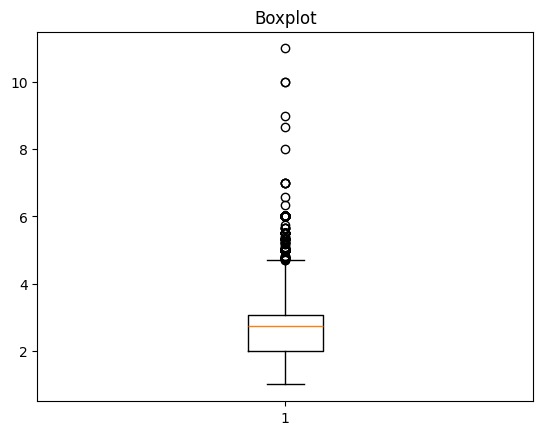

count    21838.000000
mean        13.153082
std        121.440726
min          1.000000
50%          2.000000
95%         31.000000
99%        152.000000
max      10153.000000
Name: orders_count, dtype: float64
Значений выше 95.0 процентиля (31.0): 1090 (4.99%)
Значений выше 99.0 процентиля (152.0): 216 (0.99%)


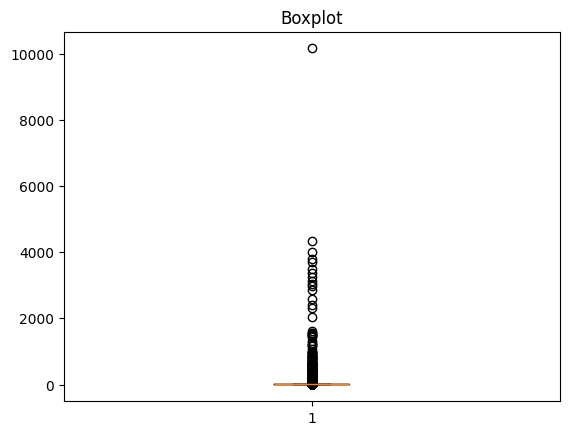

count    13511.000000
mean        15.848966
std         22.304300
min          0.000000
50%          8.000000
95%         61.500000
99%        112.000000
max        148.000000
Name: days_between, dtype: float64
Значений выше 95.0 процентиля (61.5): 673 (4.98%)
Значений выше 99.0 процентиля (112.0): 135 (1.00%)


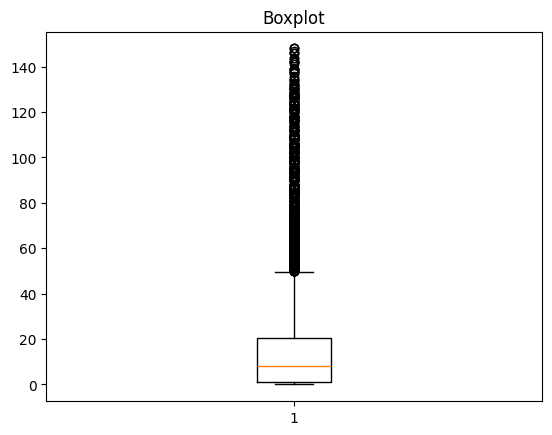

In [23]:
def describe_above_percentile(series, percentile1, percentile2):
    print(series.describe(percentiles=[0.5, percentile1, percentile2]))
    p1_val = series.quantile(percentile1)
    p2_val = series.quantile(percentile2)
    above_p1_count = series[series > p1_val].count()
    above_p2_count = series[series > p2_val].count()
    print(f"Значений выше {percentile1*100} процентиля ({p1_val}): {above_p1_count} ({(above_p1_count / series.count())*100:.2f}%)")
    print(f"Значений выше {percentile2*100} процентиля ({p2_val}): {above_p2_count} ({(above_p2_count / series.count())*100:.2f}%)")
    series = series.dropna()
    plt.boxplot(series)
    plt.title('Boxplot')
    plt.show()
    
    return p1_val, p2_val

p95_tickets, p99_tickets = describe_above_percentile(profiles['tickets_avg'], 0.95, 0.99)
p95_orders, p99_orders = describe_above_percentile(profiles['orders_count'], 0.95, 0.99)
p95_days_between, p99_days_between = describe_above_percentile(profiles['days_between'], 0.95, 0.99)

В стобцах 'tickets_avg', 'orders_count', 'days_between' обнаружены выбросы. Следует отфильтровать данные по 99 процентилю, которых в каждом стобце примерно 1%, в то время как значения выше 95 процентиля состовляют более 4.5%

In [24]:
mask_tickets = profiles['tickets_avg'] <= p99_tickets
mask_orders = profiles['orders_count'] <= p99_orders
mask_days = (profiles['days_between'] <= p99_days_between) | profiles['days_between'].isna()

final_mask = mask_tickets & mask_orders & mask_days
profiles_clean = profiles[final_mask].copy()
print(f"Исходное количество пользователей: {len(profiles)}")
print(f"После фильтрации: {len(profiles_clean)}")
print(f"Удалено: {len(profiles) - len(profiles_clean)} ({100*(1 - len(profiles_clean)/len(profiles)):.2f}%)")

Исходное количество пользователей: 21838
После фильтрации: 21293
Удалено: 545 (2.50%)


- В результате построения профилей пользователей было выявлено 21 854 уникальных пользователя со средней выручкой 544 рубля на заказ.
- Анализ поведения показал, что 61.7% пользователей совершили 2 и более заказа, а 29% пользователей - 5 и более, что говорит о достаточно высокой повторной активности аудитории.
- При анализе на аномалии выбросы были обнаружены в трёх столбцах - tickets_avg, orders_count и days_between. В качестве порога для фильтрации был выбран 99-й процентиль. В итоге было удалено 545 пользователей (2.49%), и финальная выборка составила 21 309 пользователей.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Определим, какие сегменты пользователей (по типу мероприятия, устройству, региону и билетному оператору) влияют на вероятность повторной покупки. Для каждого сегмента рассчитываем долю пользователей, совершивших 2 и более заказа (is_two). Результат визуализируем с помощью барплот, чтобы наглядно сравнить сегменты.

---

**Задача 4.1.1.** Изучим распределение пользователей по признакам.

---


In [25]:
def segment_analysis(series, name):
    counts = series.value_counts().sort_values()
    print("По", name)
    print("users_count:", counts, "share:", counts / counts.sum())

segment_analysis(profiles_clean['first_event_type'], 'типу мероприятия')
segment_analysis(profiles_clean['first_device'], 'типу устройства')
segment_analysis(profiles_clean['first_region'], 'региону')
segment_analysis(profiles_clean['first_service'], 'билетному оператору')

По типу мероприятия
users_count: first_event_type
ёлки          95
выставки     405
спорт        779
стендап     1092
театр       4180
другое      5291
концерты    9451
Name: count, dtype: int64 share: first_event_type
ёлки        0.004462
выставки    0.019020
спорт       0.036585
стендап     0.051284
театр       0.196309
другое      0.248485
концерты    0.443855
Name: count, dtype: float64
По типу устройства
users_count: first_device
desktop     3644
mobile     17649
Name: count, dtype: int64 share: first_device
desktop    0.171136
mobile     0.828864
Name: count, dtype: float64
По региону
users_count: first_region
Верхозёрский край              1
Яснопольский округ             1
Сосноводолинская область       1
Тихогорская область            2
Залесский край                 2
                            ... 
Малиновоярский округ         519
Озернинский край             669
Широковская область         1203
Североярская область        3690
Каменевский регион          6976
Name: count, 

Распределение пользователей неравномерное во всех четырёх разреза:
- По типу мероприятия - большинство концерты (43.9%)  категория другое (25.3%), театр (19.7%). Остальные жанры дают лишь 11%.
- По типу устройства - большинство первых заказов сделано с мобильного (82.9%), desktop 17.1%.
- По региону - почти треть пользователей (32.7%) в Каменевском регионе, Североярская область (17.3%).
- По билетному оператору - Билеты без проблем, Мой билет, Лови билет, Билеты в руки, Облачко 72.6% пользователей. Билеты в интернете и Дырокол не привлекли ни одного пользователя.

<hr>

<h5>Задача 4.1.2. Анализ возвратов пользователей по сегментам</h5>

<p>Для каждого сегмента рассчитываем долю пользователей, совершивших 2 и более заказа (<code>is_two</code>).</p>

<hr>

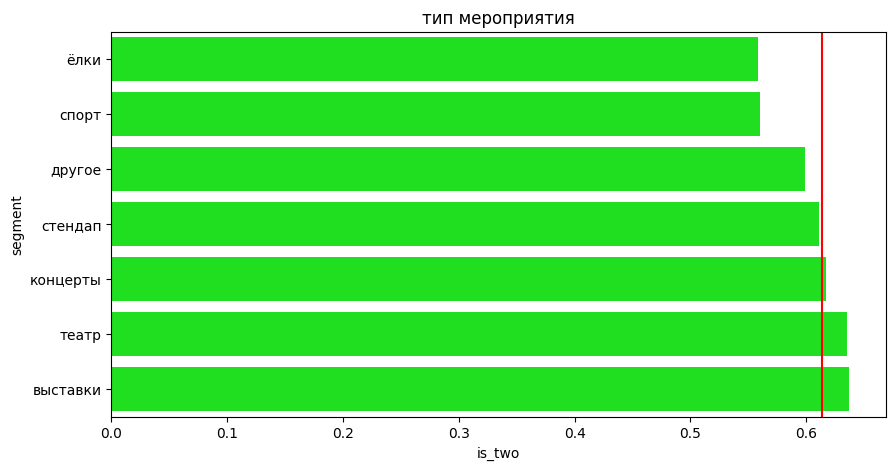

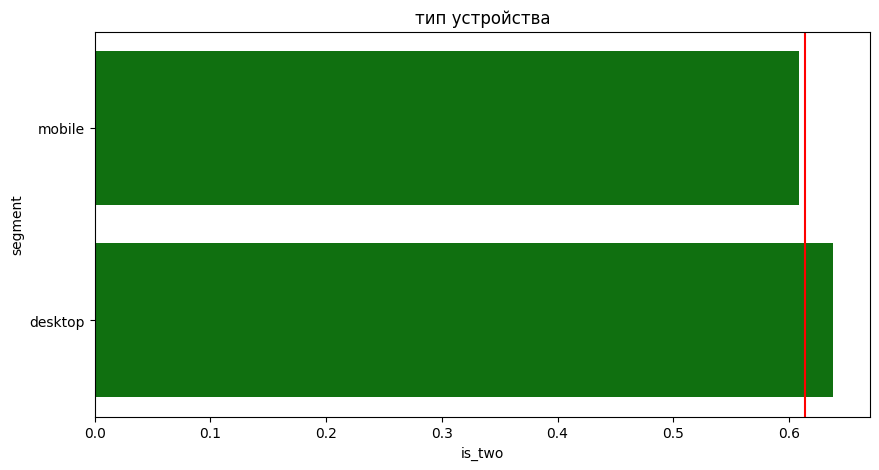

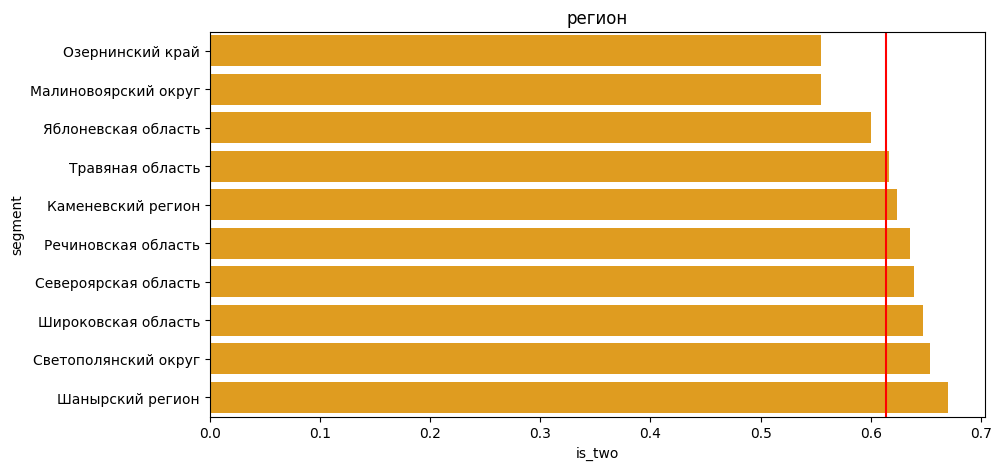

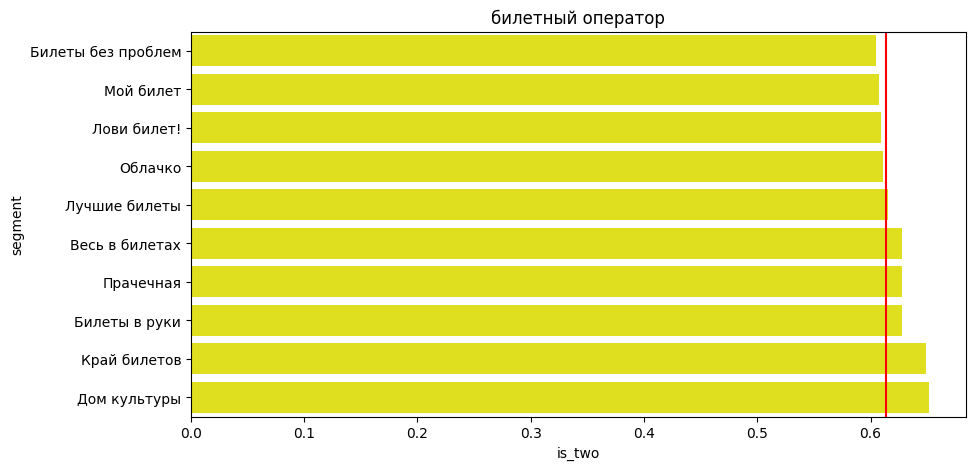

In [26]:
def plot_segment(series, name, is_two_series, color):
    df_temp = pd.DataFrame({'segment': series.astype(str), 'is_two': is_two_series})
    is_two_share = df_temp.groupby('segment')['is_two'].mean().sort_values()
    
    if len(is_two_share) > 10:
        top_segments = series.astype(str).value_counts().head(10).index
        is_two_share = is_two_share[is_two_share.index.isin(top_segments)]
    is_two_share = is_two_share.sort_values().reset_index()
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='is_two', y='segment', data=is_two_share, color=color)
    avg_return = profiles_clean['is_two'].mean()
    plt.axvline(avg_return, color='red')
    plt.title(name)
    plt.show()
plot_segment(profiles_clean['first_event_type'], 'тип мероприятия', profiles_clean['is_two'], color='lime')
plot_segment(profiles_clean['first_device'], 'тип устройства', profiles_clean['is_two'], color='green')
plot_segment(profiles_clean['first_region'], 'регион', profiles_clean['is_two'], color='orange')
plot_segment(profiles_clean['first_service'], 'билетный оператор', profiles_clean['is_two'], color='yellow')

Распределение повторных покупателей равномерное сегменты держатся в диапазоне 0.55–0.65.
- По типу мероприятия: Выставки и театр чуть выше среднего, спорт немного ниже, но разница несущественная. Жанр первого мероприятия слабо влияет на возврат.
- По типу устройства desktop-пользователи возвращаются чуть чаще чем mobile, но разница небольшая.
- По региону разброс больше чем в остальных сегментах (0.55–0.67). Шанырский регион и Светополянский округ немного выше среднего, Озернинский край и Малиновоярский округ ниже. Выраженных точек входа нет.
- По билетному оператору: Все топ-10 операторов держатся в узком диапазоне 0.60–0.65. Дом культуры и Край билетов чуть выше остальных.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Спорт ≈ 0.55, концерты ≈ 0.65 — спорт ниже, значит гипотеза 1 не подтвердилась
Регионы все в диапазоне 0.55–0.67 без явного разрыва между топ и остальными

Вопрос по 2 гипотезе что подрозумевать под малоактивными городами, если города с маленьким количеством пользователей, то данные будут не надежны, если брать только топ 10 то: По графику регион все топ-10 крупных регионов держатся в диапазоне 0.55–0.67. Гипотеза не подтверждается


<hr>

<h4>4.2. Исследование поведения пользователей через показатели выручки и состава заказа</h4>

<p>Исследуем количественные характеристики (<code>revenue_avg</code>, <code>ticket_avg</code>) заказов пользователей определим, какие влияют на вероятность повторной покупки.</p>

<hr>

<h5>Задача 4.2.1. Рассмотрим связь между средней выручкой сервиса с заказа и повторными заказами.</h5>

<hr>

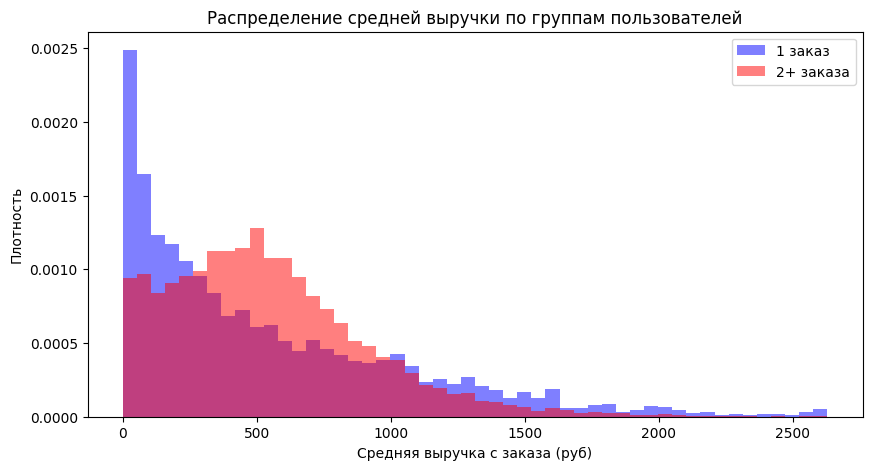

In [27]:
plt.figure(figsize=(10, 5))

labels = ['1 заказ', '2+ заказа']
colors = ['blue', 'red']

for i, label, color in zip([False, True], labels, colors):
    data = profiles_clean[profiles_clean['is_two'] == i]['revenue_avg']
    plt.hist(data, bins=50, alpha=0.5, density=True, label=label, color=color)

plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки по группам пользователей')
plt.legend()
plt.show()

В каких диапазонах концентрируются пользователи:
- С 1 заказом - пик в диапазоне 0–100 руб c большим хвостом справа, скорее всего бонусные/промо пользователи
- С 2+ заказами - пик смещён к 400–600 руб, распределение более равномерное

Вернувшиеся пользователи платят больше за каждый заказ. Группа с 1 заказом сильно отклонена влево из-за большого количества нулевых или околонулевых значений, а группа с 2+ заказами таких значений почти не имеет.

---

**Задача 4.2.2.** Сравним распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

---


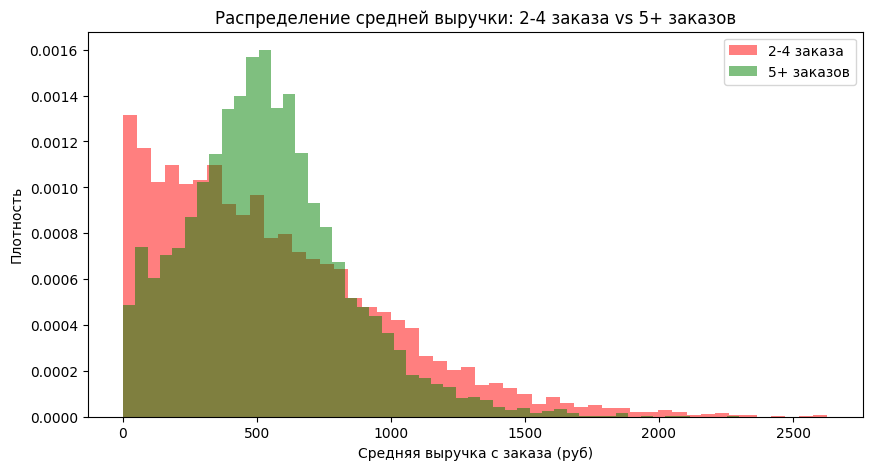

In [28]:
plt.figure(figsize=(10, 5))

labels = ['2-4 заказа', '5+ заказов']
colors = ['red', 'green']
masks = [profiles_clean['is_two'] & ~profiles_clean['is_five'], profiles_clean['is_five']]

for mask, label, color in zip(masks, labels, colors):
    data = profiles_clean[mask]['revenue_avg']
    plt.hist(data, bins=50, alpha=0.5, density=True, label=label, color=color)

plt.xlabel('Средняя выручка с заказа (руб)')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки: 2-4 заказа vs 5+ заказов')
plt.legend()
plt.show()

- 2–4 заказа — распределение неравномерное без чёткого пика, правый хвост до 2500 руб
- 5+ заказов — чёткий пик у 500 руб, распределение сконцентрированное

Вывод: пик у 500 руб на первой гистограмме в группе 2+ заказов был сформирован ипользователями с 5+ заказами. Они платят стабильно около 500 руб за заказ. Пользователи с 2–4 заказами более разнородны по среднему чеку.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

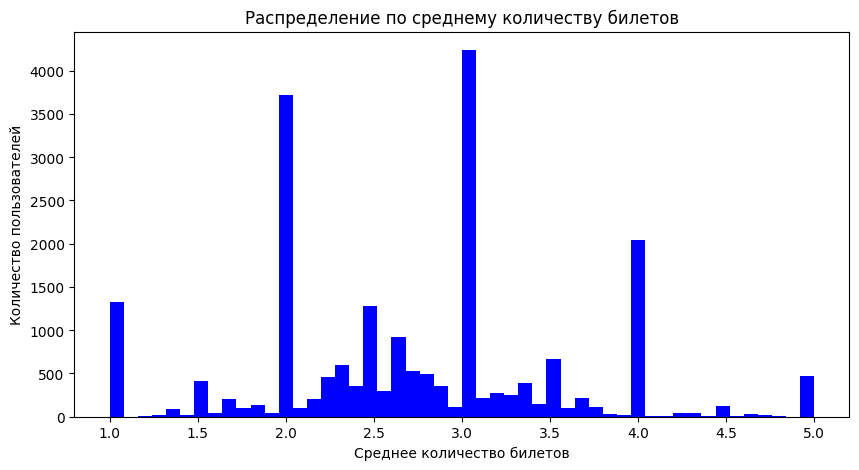

1-2 билета: users_count=2394, is_two=0.5092
2-3 билета: users_count=9436, is_two=0.7343
3-5 билетов: users_count=8997, is_two=0.5398
5+ билетов: users_count=466, is_two=0.1288


In [29]:
plt.figure(figsize=(10, 5))
plt.hist(profiles_clean['tickets_avg'], bins=50, color='blue')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.title('Распределение по среднему количеству билетов')
plt.show()

masks = [
    (profiles_clean['tickets_avg'] >= 1) & (profiles_clean['tickets_avg'] < 2),
    (profiles_clean['tickets_avg'] >= 2) & (profiles_clean['tickets_avg'] < 3),
    (profiles_clean['tickets_avg'] >= 3) & (profiles_clean['tickets_avg'] < 5),
    (profiles_clean['tickets_avg'] >= 5)
]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

for mask, label in zip(masks, labels):
    data = profiles_clean[mask]
    print(f"{label}: users_count={data.shape[0]}, is_two={data['is_two'].mean():.4f}")

Распределение сконцентрировано основная масса пользователей покупает 2–3 билета за заказ.
Доля повторных покупок по сегментам:
- 1-2 билета 2419 пользователей, is_two=0.51 чуть ниже среднего
- 2-3 билета 9706 пользователей, is_two=0.74 самая высокая доля возврата
- 3-5 билетов 9068 пользователей, is_two=0.54 средний показатель
- 5+ билетов 661 пользователь, is_two=0.19 - низкая доля возврата

<hr>

<h4>4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки</h4>

<p>Изучим временные параметры, связанные с первым заказом пользователей:</p>
<ul>
    <li>день недели первой покупки</li>
    <li>время с момента первой покупки</li>
    <li>средний интервал между покупками пользователей с повторными заказами</li>
</ul>

<hr>

<h5>Задача 4.3.1. Проанализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.</h5>

<hr>

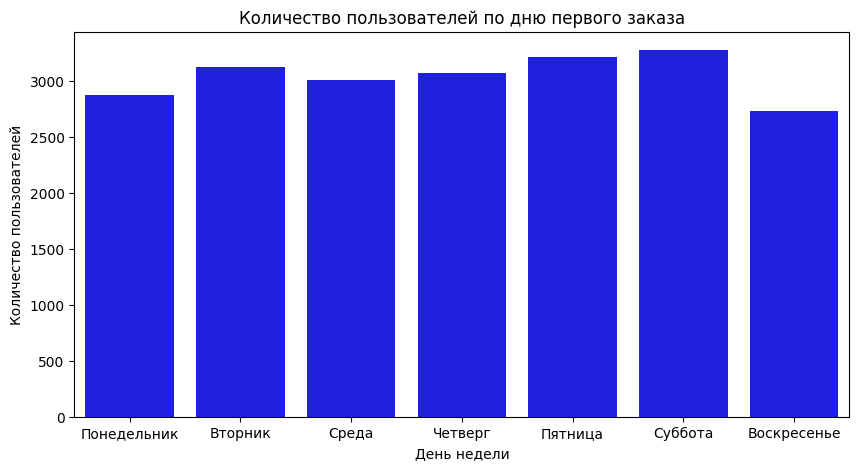

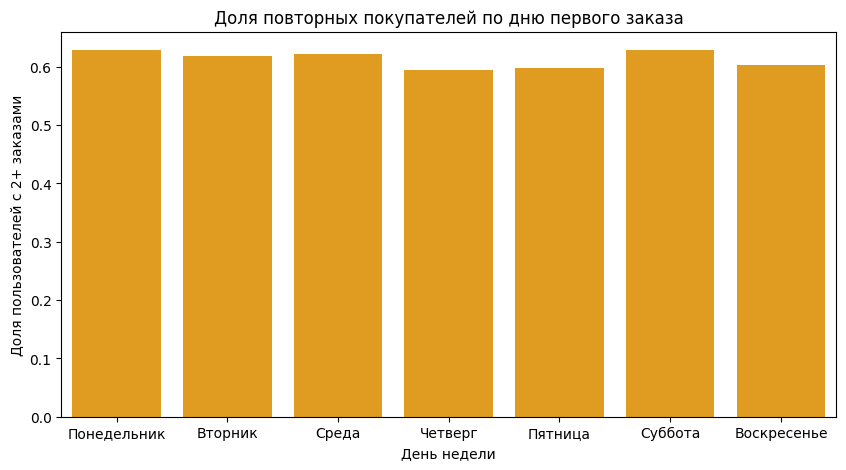

In [30]:
profiles_clean['first_order_dow'] = profiles_clean['first_order_dt'].dt.dayofweek

day_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
users_counts = []
is_two_shares = []

for day in range(7):
    data = profiles_clean[profiles_clean['first_order_dow'] == day]
    users_counts.append(data.shape[0])
    is_two_shares.append(data['is_two'].mean())

plt.figure(figsize=(10, 5))
sns.barplot(x=day_names, y=users_counts, color='blue')
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')
plt.title('Количество пользователей по дню первого заказа')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=day_names, y=is_two_shares, color='orange')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей с 2+ заказами')
plt.title('Доля повторных покупателей по дню первого заказа')
plt.show()

- Количество пользователей распределено равномерно по всем дням от 2700 в воскресенье до 3200 в субботу, без выбросов.
- Доля повторных покупок почти одинакова во все дни от примерно 0.59 до 0.62.
- День недели первого заказа не влияет на вероятность возврата пользователя.

---

**Задача 4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.

---


2-4 заказа
users_count: 6961
days_between_avg: 19.44
5+ заказов
users_count: 6104
days_between_avg: 9.92


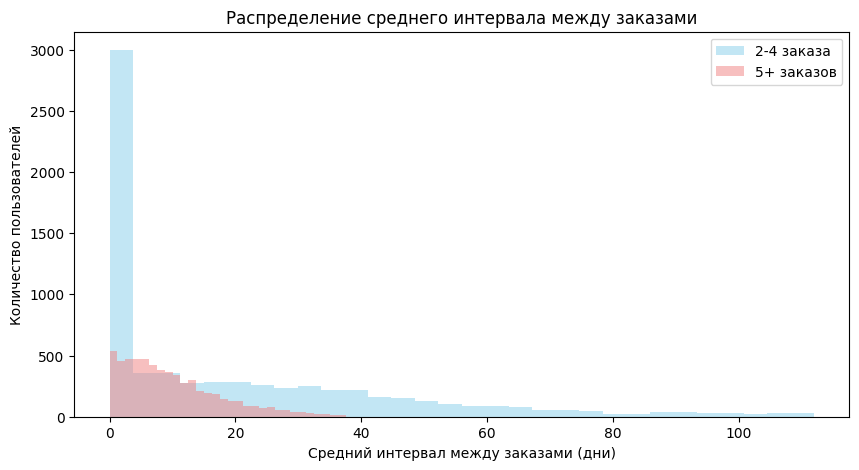

In [31]:
masks = [profiles_clean['is_two'] & ~profiles_clean['is_five'], profiles_clean['is_five'] ]
labels = ['2-4 заказа', '5+ заказов']
colors = ['skyblue', 'lightcoral']
plt.figure(figsize=(10, 5))

for mask, label, color in zip(masks, labels, colors):
    data = profiles_clean[mask]
    print(label)
    print('users_count:', data.shape[0])
    print('days_between_avg:', data['days_between'].mean().round(2))
    plt.hist(data['days_between'].dropna(), bins=30, alpha=0.5, label=label, color=color)

plt.xlabel('Средний интервал между заказами (дни)')
plt.ylabel('Количество пользователей')
plt.title('Распределение среднего интервала между заказами')
plt.legend()
plt.show()

Вывод: Чем больше заказов совершает пользователь, тем короче интервал между ними - у группы 2–4 заказа среднее время между заказами составляет 19 дней, у лояльных пользователей с 5+ заказами 10 дней.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучим, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок, используя универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитаем коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). Используем параметр `interval_cols` для определения интервальных данных.
---

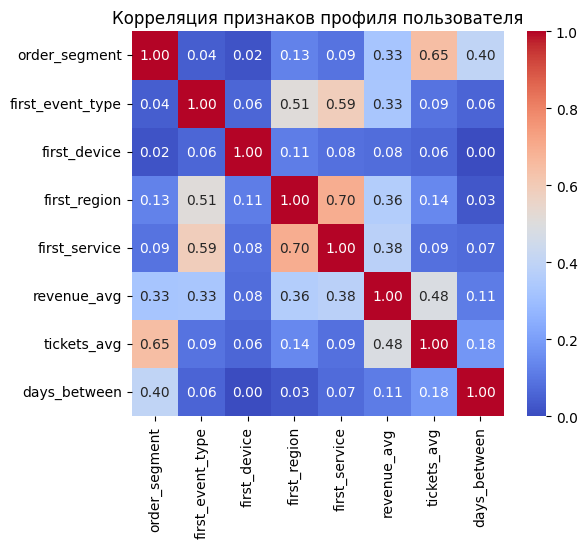

In [32]:
def order_segment(x):
    if x == 1:
        return '1 заказ'
    elif x <= 4:
        return '2-4 заказа'
    else:
        return '5+ заказов'

profiles_clean['order_segment'] = profiles_clean['orders_count'].apply(order_segment)

interval_cols = ['revenue_avg', 'tickets_avg', 'days_between']

corr = profiles_clean[[
    'order_segment', 'first_event_type', 'first_device',
    'first_region', 'first_service', 'revenue_avg',
    'tickets_avg', 'days_between'
]].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция признаков профиля пользователя')
plt.show()

Корреляционная матрица подтвердила результаты предыдущего анализа. Наиболее связанные с order_segment признаки:
- tickets_avg - 0.65 подтверждает что пользователи берущие 2–3 билета возвращаются чаще
- days_between - 0.40 подтверждает вывод о лояльных пользователях с 5+ заказами
- revenue_avg - 0.33 вернувшиеся пользователи платят больше за каждый заказ

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

## Вывод:
- После предобработки(перевода тенге в рубли, оптимизации типов данных и фильтрации выбросов по 99-му перцентилю) осталось 21 309 пользователей.
- Информация о пользователях: 61.7% совершили 2 и более заказа, 29% совершили 5 и более. Средняя выручка с заказа составила 544 рубля.
- Признаки жанр мероприятия, тип устройства, регион и билетный оператор почим не влияют на вероятность возврата. Все сегменты держатся в диапазоне 0.55 - 0.65, без выраженных точек входа. Гипотезы о влиянии жанра и региона не подтвердились.
- Пользователи с 1 заказом концентрируются в диапазоне 0–100 руб. Пользователи с 5+ заказами платят стабильно около 500 руб за заказ.
- Наибольшая доля повторных покупок у пользователей берущих 2–3 билета (0.74), наименьшая у берущих 5+ билетов (0.19).
- Пользователи с 5+ заказами возвращаются в среднем каждые 10 дней, группа с 2–4 заказами 19 дней.
- Корреляционный анализ подтвердил все выводы наиболее связаны с количеством заказов среднее количество билетов (0.65) и средняя выручка (0.33).
## Рекомедации:
- Количество билетов влияет на вероятность повторного заказ. Так в пользователи совершившие 2 и более покупок приобретают в основном 2 - 3 билета нужно сосредоточить внимание на нихю. К примеру давать скидки за покупку 2 и более билетов в 1 заказе или реализовать возможность создавать группы пользователей в приложение и реализовывать групповые мерояприятияю
- В среднес люди совершившие большее количество заказов имеют и более высокий средний чек. Имеет смысл ввести статус вип-пользователей для подобных лояльных клиентов.
- Большая доля пользователей с 1 заказом сосредоточена в диапазоне 0–100 руб скорее всего это промо-пользователи привлечённые бонусами. Имеет смысл проработать механику второго заказа для этой группы(персональное предложение после первой покупки по промокоду).